In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import glob 
import os
print(os.getcwd())

/home/savvyfox/Projects/scg-exp/examples/rl


In [2]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w) / w, mode='valid')
    
def load_from_log_file(path):
    '''Return x, y sequence data from the stat csv.'''
    with open(path, 'r') as f:
        lines = f.readlines()
    # Labels.
    xk, yk = [k.strip() for k in lines[0].strip().split(',')]
    # Values.
    x, y = [], []
    for line in lines[1:]:
        data = line.strip().split(',')
        x.append(float(data[0].strip()))
        y.append(float(data[1].strip()))
    x = np.array(x)
    y = np.array(y)
    return xk, x, yk, y

In [3]:
plot_colors = {
    'GP-MPC': 'royalblue',
    'PPO': 'darkorange',
    'SAC': 'red',
    'DPPO': 'pink',
    'PPO-MPC': 'tan',
    'iLQR': 'darkgray',
    'Linear MPC': 'green',
    'Nonlinear MPC': 'cadetblue',
    "iLQR": "tab:gray",
    'MAX': 'none',
    'MIN': 'none',
}

legends = {
    "ref": "black",
    "PPO": "PPO",
    "PPO3": "PPO with ilqr ref",
    "PPO4": "PPO with ilqr state ref",
    "SAC": "SAC",
    "TD3": "TD3",
    "DPPO": "DPPO",
    "GP-MPC": "GP-MPC",
    "PPO-MPC": "PPO-MPC"
}

In [4]:
#data_dir = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/prefinal"

#data_dir = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/prefinal_ilqr_ref"
data_dir1 = "/home/savvyfox/Misc/Olaf/Projects/scg-exp/examples/rlmpc/Results/ppo_mpc_update"
data_dir0 = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/final_7"
data_dir2 = "/home/savvyfox/Misc/lsy_workstation_06/Projects/scg-exp/examples/rl/Results/final2"
data_dir4 = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/final"
exp_name = "nominal"
data_paths = {
    "PPO": data_dir2 + "/" + exp_name + "/quadrotor_2D_attitude_ppo_data",
    "SAC": data_dir2 + "/" + exp_name + "/quadrotor_2D_attitude_sac_data",
    "DPPO": data_dir2 + "/" + exp_name + "/quadrotor_2D_attitude_dppo_data",
    #"PPO-MPC": data_dir1 + "/quadrotor_2D_attitude_ppo_mpc_data8",
}

### Convergence plot

In [5]:
perf_data = {}
for method in data_paths.keys():
    print(method)
    perf_data.update({method: {}})
    temp = [x for x in os.listdir(data_paths[method])]
    for sd in os.listdir(data_paths[method]):
        seed = sd[4]
        xk, x, lk, l = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/ep_length.log")
        xk, x, yk, y = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/ep_return.log")
        xk, x, zk, z = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/ep_return_std.log")
        # xk, x, ck, c = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/constraint_violation.log")
        xk, x, yk, m = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/rmse.log")
        xk, x, yk, n = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/rmse_std.log")
        # perf_data[method].update({"x": x, "y": y, "z": z, "x1": x1, "y1": y1, "z1": z1})
        perf_data[method].update({int(seed): {"data": x, "ep_return": y, "ep_return_std": z, "rmse": m, "rmse_std": n, "ep_length": l}})

PPO
SAC
DPPO


In [121]:
gp_name = '/gpmpc_acados_TP_hpo_convergence_results.npy'
gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
gp_mpc_data['rmse'][:,-1].mean()

0.019031737833333003

PPO
[       nan        nan        nan 1.20938301 0.60452909 0.64660848
 0.40564388 0.28638926 0.1954007  0.45679755 0.29199143 0.44170029
 0.33000254 0.25977536 0.22527336 0.17195722 0.14005851 0.13175518
 0.09575283 0.0762673  0.06549011 0.09029636 0.05680356 0.06112542
 0.05376794 0.05882376 0.04866779 0.04907583 0.04641233 0.05078621
 0.03829331 0.04065529 0.04274317 0.04687672 0.03476641 0.03658463
 0.04747279 0.03461575 0.03429906 0.03044253 0.03191751 0.03119718
 0.02536638 0.02872748 0.03593227 0.02878992 0.02643394 0.0273588
 0.02539763 0.02925456 0.02502219 0.0255806  0.02905143 0.03078192
 0.03050318 0.02412    0.02472903 0.02640424 0.03148935 0.02511058
 0.02261322 0.02504671 0.0259149  0.03277274 0.02620477 0.0232021
 0.02122664 0.02563728 0.02610648 0.0235574  0.02595581 0.02446631
 0.02524526 0.02266344 0.02491453 0.02221992 0.02337418 0.02653381
 0.02185401 0.02158841 0.02546168 0.02272544 0.01910306 0.02741393
 0.02333337 0.0242857  0.02215277 0.02425603 0.02101419 0.02

/home/savvyfox/.local/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


Text(0, 0.5, 'rmse')

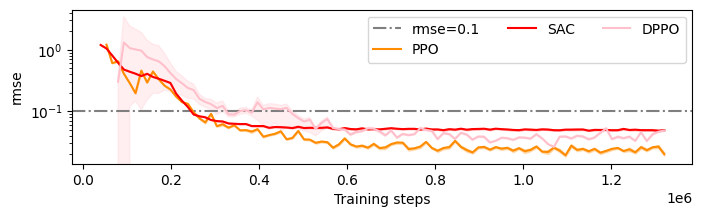

In [7]:
eval_data = {}
mean_fn = np.nanpercentile
perc = 80
n_seeds = 10
seeds = [i for i in range(0, n_seeds)]

fig = plt.figure(figsize=(8, 2)) 
plt.axhline(xmin=0.0, xmax=1.95, y=0.1, linestyle='-.', color=plot_colors["iLQR"], label='rmse=0.1')

# plt.plot(gp_mpc_data['train_steps'], mean_fn(gp_mpc_data['rmse'], perc, axis=0), color=plot_colors["GP-MPC"], label='GP-MPC')
# plt.fill_between(gp_mpc_data['train_steps'], 
#                 np.clip(mean_fn(gp_mpc_data['rmse'], perc, axis=0)-gp_mpc_data['rmse'].std(axis=0), 0, 10), 
#                 np.clip(mean_fn(gp_mpc_data['rmse'], perc, axis=0)+gp_mpc_data['rmse'].std(axis=0), 0, 10), 
#                 color=plot_colors["GP-MPC"], alpha=0.25)

for t, method in enumerate(data_paths.keys()):
    print(method)
    temp = np.zeros((n_seeds, 6, perf_data[method][seeds[0]]["data"].shape[0]))
    for seed in seeds:
        temp[seed, 0, :] = perf_data[method][seed]["data"]
        temp[seed, 1, :] = perf_data[method][seed]["ep_return"]
        temp[seed, 2, :] = perf_data[method][seed]["ep_return_std"]
        temp[seed, 3, :] = perf_data[method][seed]["rmse"]
        temp[seed, 4, :] = perf_data[method][seed]["rmse_std"]
        temp[seed, 5, :] = perf_data[method][seed]["ep_length"]
    j_max = 0
    for seed in seeds:
        for j,k in enumerate(temp[seed, 0, :]):
            if temp[seed, 5, j] < 540:
                temp[seed, 1, j] = np.nan
                temp[seed, 2, j] = np.nan
                temp[seed, 3, j] = np.nan
                temp[seed, 4, j] = np.nan
                if j >= j_max:
                    j_max = j+1
    eval_data.update({method: temp})
    print(mean_fn(temp[:,3,:], perc, axis=0))
    print(temp[0,0,:])

    plt.plot(temp[0,0,:]+1, mean_fn(temp[:,3,:], perc, axis=0), color=plot_colors[method], label=legends[method])
    plt.fill_between(temp[0,0,:]+1, 
                     np.clip(mean_fn(temp[:,3,:]-temp[:,4,:], perc, axis=0), 0, 10),  
                     np.clip(mean_fn(temp[:,3,:]+temp[:,4,:], perc, axis=0), 0, 10), color=plot_colors[method], alpha=0.25)

plt.legend(ncol=3)
# plt.xlim(-10000, 460000)
# plt.xlim(1, 800000)
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training steps")
plt.ylabel("rmse")
# plt.title("Task: Quadrotor 2D")
# plt.savefig("performance_logx.pdf",bbox_inches="tight", pad_inches=0.1)

### Performance metric

In [8]:
perf_metric = {}
for method in data_paths.keys():
    print(method)
    perf_metric.update({method: {'rmse': [], 'rmse_std': [], 'success': []}})
    for seed in seeds:
        path = data_paths[method] + "/seed"+ str(seed) +"_*/perf_metric.npy"
        file_path = glob.glob(path)
        temp = np.load(file_path[0], allow_pickle=True).item()
        perf_metric[method]['rmse'].append(temp['rmse'])
        perf_metric[method]['rmse_std'].append(temp['rmse_std'])
        temp2 = True if temp['average_length'] == 660.0 else False
        perf_metric[method]['success'].append(temp2)
print(f"Performance of PPO is {np.array(perf_metric['PPO']['rmse']).mean()} +/- {np.array(perf_metric['PPO']['rmse']).std()}")
print(f"Performance of SAC is {np.array(perf_metric['SAC']['rmse']).mean()} +/- {np.array(perf_metric['SAC']['rmse']).std()}")
print(f"Performance of DPPO is {np.array(perf_metric['DPPO']['rmse']).mean()} +/- {np.array(perf_metric['DPPO']['rmse']).std()}")
# print(f"Performance of PPO-MPC is {np.array(perf_metric['PPO-MPC']['rmse']).mean()} +/- {np.array(perf_metric['PPO-MPC']['rmse']).std()}")

PPO
SAC
DPPO
Performance of PPO is 0.012392725890254096 +/- 0.0020101675302201796
Performance of SAC is 0.043913860895616476 +/- 0.0014412244659338358
Performance of DPPO is 0.024098538356387197 +/- 0.01987897057705239


### Generalization metric

In [10]:
transfer_metric = {}
for method in data_paths.keys():
    print(method)
    transfer_metric.update({method: {'rmse': [], 'rmse_std': [], 'success': []}})
    for seed in seeds:
        path = data_paths[method] + "/seed"+ str(seed) +"_*/transfer_metric_11.npy"
        file_path = glob.glob(path)
        # print(data_paths[method])
        # print(file_path)
        temp = np.load(file_path[0], allow_pickle=True).item()
        transfer_metric[method]['rmse'].append(temp['rmse'])
        transfer_metric[method]['rmse_std'].append(temp['rmse_std'])
        temp2 = True if temp['average_length'] == 660.0 else False
        transfer_metric[method]['success'].append(temp2)
print(f"Performance of PPO is {np.array(transfer_metric['PPO']['rmse']).mean()} +/- {np.array(transfer_metric['PPO']['rmse']).std()}")
print(f"Performance of SAC is {np.array(transfer_metric['SAC']['rmse']).mean()} +/- {np.array(transfer_metric['SAC']['rmse']).std()}")
print(f"Performance of DPPO is {np.array(transfer_metric['DPPO']['rmse']).mean()} +/- {np.array(transfer_metric['DPPO']['rmse']).std()}")
#print(f"Performance of PPO-MPC is {np.array(transfer_metric['PPO-MPC']['rmse']).mean()} +/- {np.array(transfer_metric['PPO-MPC']['rmse']).std()}")

PPO
SAC
DPPO
Performance of PPO is 0.012541422451513578 +/- 0.0021562459323781103
Performance of SAC is 0.043931424639674255 +/- 0.0014851640064337363
Performance of DPPO is 0.023638389603038247 +/- 0.01805515731408965


In [11]:
episode_len_list = [9, 10, 11, 12, 13, 14, 15]
episode_len_list2 = [4.5, 5, 5.5, 6, 6.5, 7, 7.5]
transfer_metric = {}
for method in data_paths.keys():
    print(method)
    transfer_metric.update({method: {'rmse': [], 'rmse_std': []}})
    for T in episode_len_list:
        rmse, rmse_std = [], []
        for seed in seeds:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/transfer_metric_"+str(T)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            rmse.append(temp['rmse'])
            rmse_std.append(temp['rmse_std'])
        transfer_metric[method]['rmse'].append(np.array(rmse).mean())
        transfer_metric[method]['rmse_std'].append(np.array(rmse_std).mean())
    transfer_metric[method]['rmse'] = np.array(transfer_metric[method]['rmse'])
    transfer_metric[method]['rmse_std'] = np.array(transfer_metric[method]['rmse_std'])

PPO
SAC
DPPO


In [97]:
# gp_name = exp_name + '/gpmpc_acados_TP_tr_gen_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# print(gp_mpc_data)
# dummy_list = ['_9', '_10', '_11', '_12', '_13', '_14', '_15']
# gpmpc_gen = {'rmse': [], 'rmse_std': []}
# for i in dummy_list:
#     gpmpc_gen['rmse'].append(gp_mpc_data[i]['mean_rmse'])
#     gpmpc_gen['rmse_std'].append(gp_mpc_data[i]['std_rmse'])

PPO
DPPO
SAC


Text(0, 0.5, 'rmse')

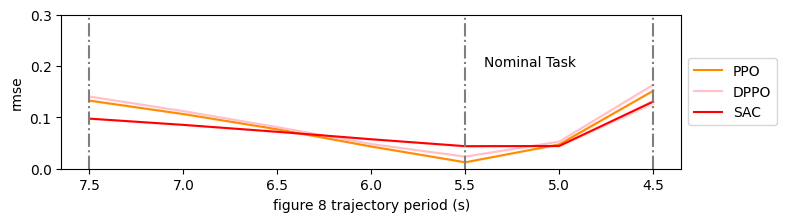

In [12]:
fig = plt.figure(figsize=(8, 2))
plot_list = [
    'PPO', 'DPPO', 'SAC', #'PPO-MPC'
]
for method in plot_list:
    print(method)
    plt.plot(episode_len_list2, transfer_metric[method]['rmse'], label=method, color=plot_colors[method])
    plt.fill_between(episode_len_list2, 
                     transfer_metric[method]['rmse']-transfer_metric[method]['rmse_std'],  
                     transfer_metric[method]['rmse']+transfer_metric[method]['rmse_std'], color=plot_colors[method], alpha=0.1)

# plt.plot(episode_len_list2, gpmpc_gen['rmse'], label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(episode_len_list2, 
#                  np.array(gpmpc_gen['rmse'])-np.array(gpmpc_gen['rmse_std']),  
#                  np.array(gpmpc_gen['rmse'])+np.array(gpmpc_gen['rmse_std']), color=plot_colors['GP-MPC'], alpha=0.1)

plt.axvline(x=5.5, linestyle='-.', color=plot_colors['iLQR'])
plt.axvline(x=7.5, linestyle='-.', color=plot_colors['iLQR'])
plt.axvline(x=4.5, linestyle='-.', color=plot_colors['iLQR'])
plt.text(5.4, 0.2, 'Nominal Task')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(0,0.3)
#plt.xlim(0,50)
plt.gca().invert_xaxis()
plt.xlabel("figure 8 trajectory period (s)")
plt.ylabel("rmse")
# plt.savefig("generalization_curve.pdf",bbox_inches="tight", pad_inches=0.1)

In [192]:
transfer_metric

{'PPO': {'rmse': array([0.1367247 , 0.06735481, 0.05744643, 0.07012763, 0.08905895,
         0.1081827 , 0.12597461]),
  'rmse_std': array([0.00102252, 0.00061589, 0.00067894, 0.00065711, 0.00076126,
         0.00081232, 0.00088197])},
 'SAC': {'rmse': array([0.26879758, 0.22334088, 0.22522494, 0.2309307 , 0.23904611,
         0.25081815, 0.26743613]),
  'rmse_std': array([0.00524019, 0.00088533, 0.00097734, 0.00077863, 0.00088515,
         0.00079227, 0.00113229])},
 'DPPO': {'rmse': array([0.20101124, 0.10703425, 0.09415894, 0.11088598, 0.13809608,
         0.16592393, 0.19350142]),
  'rmse_std': array([0.0018157 , 0.00453665, 0.0008811 , 0.00116835, 0.00139075,
         0.00135726, 0.00123366])}}

### Robustness metric: Observation noise

In [17]:
metric = {}
noise_scale = [0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
noise_scale = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
for method in data_paths.keys():
    print(method)
    metric.update({method: {}})
    for seed in seeds:
        for ns in noise_scale:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_ob_"+str(ns)+".npy"
            #print(path)
            file_path = glob.glob(path)
            #print(file_path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            if ns in metric[method].keys():
                metric[method][ns]['rmse'].append(temp['rmse'])
                metric[method][ns]['rmse_std'].append(temp['rmse_std'])
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method][ns]['success'].append(temp2)
            else:
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method].update({ns: {'rmse': [temp['rmse']], 
                                            'rmse_std': [temp['rmse_std']], 
                                            'success': [temp2]}})

PPO
SAC
DPPO


PPO
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
50
[ 100.           99.37921674  100.30543969  100.3145935   103.46769391
  104.5232145   108.08596369  112.24089968  117.14689993  124.34810562
  135.15762284  149.0010548   181.03757855  198.87881388  242.6444747
  268.04982723  368.41328439  472.018384    616.05783847  734.30812585
  878.64824676 1014.41567001 1313.95684487 1632.67865011 1942.34577971
 2273.03784219 2634.21283965]
SAC
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
50
[100.          99.62203911  99.67934721  99.63230289  99.62500734
  99.60813989  99.70752706  99.54741607  99.12974638  99.5480061
  99.46981388  99.37943024  99.38825617  99.9328073   99.39430816
  99.77098134  99.543213    99.90664982 100.40163558 100.61363604
 101.54173458 102.29816769 103.86628182 108.33776542 112.08687381
 117.37339896 125.22727276]
DPPO
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 1

Text(0, 0.5, 'Relative Performance %')

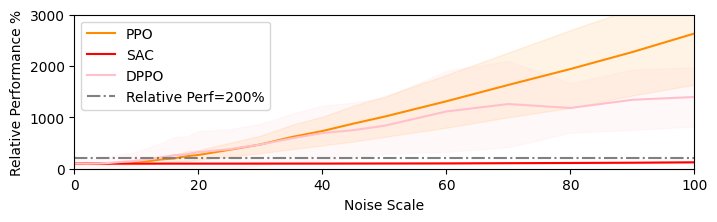

In [18]:
fig = plt.figure(figsize=(8, 2))
for method in metric.keys():
    print(method)
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 50
    count = 50
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    print(noise_scale)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)
    
    #plt.plot(noise_scale[:count+1], temp[:count+1]*100/temp[0], color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(noise_scale[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    print(temp*100/temp[0])
    ddd = 100/temp[0]
    plt.plot(noise_scale, temp*ddd, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

# ddd = 100/gp_mpc_data['rmse_mean'][0]
# plt.plot(noise_scale, gp_mpc_data['rmse_mean'][:13]*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(noise_scale, 
#                  (gp_mpc_data['rmse_mean'][:13]-gp_mpc_data['rmse_std'][:13])*ddd,  
#                  (gp_mpc_data['rmse_mean'][:13]+gp_mpc_data['rmse_std'][:13])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)

plt.plot(noise_scale, [200]*len(noise_scale), color='grey', linestyle='-.', label='Relative Perf=200%')
# plt.plot(noise_scale, [0.1]*len(noise_scale), color='grey', linestyle='-.', label='rmse=0.1')

#plt.text(16, 500, 'PPO \nearly stop')
#plt.text(31, 500, 'SAC \nearly stop')
#plt.text(16, 2500, 'DPPO \nearly stop')


plt.legend()
plt.ylim(0,3000)
# plt.ylim(0,1.0)
plt.xlim(0,100)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Noise Scale")
plt.ylabel("Relative Performance %")
# plt.ylabel("% rmse degradation")
#plt.title("TD3 for Quadrotor 2D")
# plt.savefig("robustness_ob_rl.pdf",bbox_inches="tight", pad_inches=0.1)

PPO
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
50
[ 100.           99.37921674  100.30543969  100.3145935   103.46769391
  104.5232145   108.08596369  112.24089968  117.14689993  124.34810562
  135.15762284  149.0010548   181.03757855  198.87881388  242.6444747
  268.04982723  368.41328439  472.018384    616.05783847  734.30812585
  878.64824676 1014.41567001 1313.95684487 1632.67865011 1942.34577971
 2273.03784219 2634.21283965]
SAC
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
50
[100.          99.62203911  99.67934721  99.63230289  99.62500734
  99.60813989  99.70752706  99.54741607  99.12974638  99.5480061
  99.46981388  99.37943024  99.38825617  99.9328073   99.39430816
  99.77098134  99.543213    99.90664982 100.40163558 100.61363604
 101.54173458 102.29816769 103.86628182 108.33776542 112.08687381
 117.37339896 125.22727276]
DPPO
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 1

Text(0, 0.5, 'rmse')

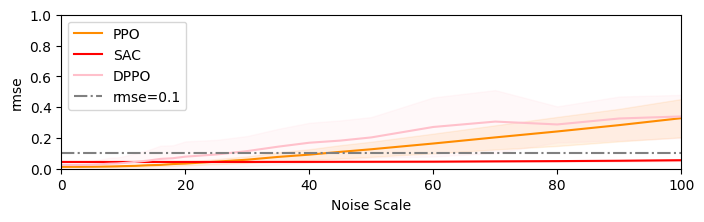

In [19]:
fig = plt.figure(figsize=(8, 2))
for method in metric.keys():
    print(method)
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 50
    count = 50
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    print(noise_scale)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)
    
    #plt.plot(noise_scale[:count+1], temp[:count+1]*100/temp[0], color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(noise_scale[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    print(temp*100/temp[0])
    ddd = 1 #00/temp[0]
    plt.plot(noise_scale, temp*ddd, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

# ddd = 100/gp_mpc_data['rmse_mean'][0]
# plt.plot(noise_scale, gp_mpc_data['rmse_mean'][:13]*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(noise_scale, 
#                  (gp_mpc_data['rmse_mean'][:13]-gp_mpc_data['rmse_std'][:13])*ddd,  
#                  (gp_mpc_data['rmse_mean'][:13]+gp_mpc_data['rmse_std'][:13])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)

# plt.plot(noise_scale, [200]*len(noise_scale), color='grey', linestyle='-.', label='Relative Perf=200%')
plt.plot(noise_scale, [0.1]*len(noise_scale), color='grey', linestyle='-.', label='rmse=0.1')

#plt.text(16, 500, 'PPO \nearly stop')
#plt.text(31, 500, 'SAC \nearly stop')
#plt.text(16, 2500, 'DPPO \nearly stop')


plt.legend()
# plt.ylim(0,3000)
plt.ylim(0,1.0)
plt.xlim(0,100)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Noise Scale")
# plt.ylabel("Relative Performance %")
plt.ylabel("rmse")
#plt.title("TD3 for Quadrotor 2D")
# plt.savefig("robustness_ob_rl.pdf",bbox_inches="tight", pad_inches=0.1)

## Robustness metric: Process Noise

In [20]:
metric = {}
noise_scale = [0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50]
noise_scale = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
for method in data_paths.keys():
    print(method)
    metric.update({method: {}})
    for seed in seeds:
        for ns in noise_scale:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_ps_"+str(ns)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            if ns in metric[method].keys():
                metric[method][ns]['rmse'].append(temp['rmse'])
                metric[method][ns]['rmse_std'].append(temp['rmse_std'])
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method][ns]['success'].append(temp2)
            else:
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method].update({ns: {'rmse': [temp['rmse']], 
                                            'rmse_std': [temp['rmse_std']], 
                                            'success': [temp2]}})

PPO
SAC
DPPO


In [154]:
# gp_name =  'ps5/gpmpc_acados_TP_proc_ns=5_proc_noise_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# print(gp_mpc_data['rmse_mean'][:13])
# print(gp_mpc_data.keys())

PPO
25
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
[ 100.          106.73568001  126.58704561  165.29956538  234.20959987
  290.51019592  374.17434388  492.17637535  581.84489907  672.47756806
  801.68594103 1013.12722218 1287.28484484 1608.34920089 1838.05194689
 2148.15196399 2870.14599409 3639.53666125 4186.45890639 4838.8982777
 5338.52901036 5875.10854685 6512.5971605  6911.50751488 6966.8231983
 7252.45297462 7174.48143779]
SAC
8
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
[ 100.          100.03920408  100.15292553   99.34384515  107.81868356
  143.0729815   204.17691589  362.85461385  602.73068325  803.86385882
  937.34850911 1038.87962433 1135.32591644 1224.03200742 1368.23914241
 1402.10433614 1542.71849819 1694.88426717 1656.71398007 1630.45001622
 1726.87042203 1571.23293573 1620.81901317 1777.81349436 1674.52035157
 1812.23466752 1718.0642095 ]
DPPO
20
[0, 1, 2, 3

Text(0, 0.5, 'Relative Performance %')

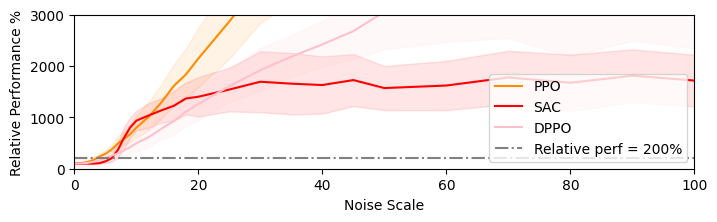

In [21]:
fig = plt.figure(figsize=(8, 2))
for method in metric.keys():
    print(method)
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 200
    count = 0
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - 1*data.std())
        temp_std2.append(data.mean() + 1*data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)
    
    
    #plt.plot(noise_scale[:count+1], temp[:count+1]*100/temp[0], color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(noise_scale[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    print(noise_scale)
    print(temp*100/temp[0])
    ddd = 100/temp[0]
    plt.plot(noise_scale, temp*ddd, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)
ddd= 1#100/gp_mpc_data['rmse_mean'][0]
# plt.plot(noise_scale, gp_mpc_data['rmse_mean'][:13]*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(noise_scale, 
#                  (gp_mpc_data['rmse_mean'][:13]-gp_mpc_data['rmse_std'][:13])*ddd,  
#                  (gp_mpc_data['rmse_mean'][:13]+gp_mpc_data['rmse_std'][:13])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)

plt.plot(noise_scale, [200]*len(noise_scale), color='grey', linestyle='-.', label='Relative perf = 200%')
# plt.plot(noise_scale, [0.1]*len(noise_scale), color='grey', linestyle='-.', label='rmse=0.1')

#plt.text(41, 2000, 'PPO \nearly stop')
#plt.text(6, 1500, 'SAC \nearly stop')
#plt.text(31, 1000, 'DPPO \nearly stop')


plt.legend()
plt.ylim(0,3000)
#plt.ylim(0,0.8)
plt.xlim(0,100)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Noise Scale")
plt.ylabel("Relative Performance %")
# plt.ylabel("% rmse degradation")
#plt.title("TD3 for Quadrotor 2D")
#plt.savefig("robustness_ps_rl.pdf",bbox_inches="tight", pad_inches=0.1)

PPO
25
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
[ 100.          106.73568001  126.58704561  165.29956538  234.20959987
  290.51019592  374.17434388  492.17637535  581.84489907  672.47756806
  801.68594103 1013.12722218 1287.28484484 1608.34920089 1838.05194689
 2148.15196399 2870.14599409 3639.53666125 4186.45890639 4838.8982777
 5338.52901036 5875.10854685 6512.5971605  6911.50751488 6966.8231983
 7252.45297462 7174.48143779]
SAC
8
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
[ 100.          100.03920408  100.15292553   99.34384515  107.81868356
  143.0729815   204.17691589  362.85461385  602.73068325  803.86385882
  937.34850911 1038.87962433 1135.32591644 1224.03200742 1368.23914241
 1402.10433614 1542.71849819 1694.88426717 1656.71398007 1630.45001622
 1726.87042203 1571.23293573 1620.81901317 1777.81349436 1674.52035157
 1812.23466752 1718.0642095 ]
DPPO
20
[0, 1, 2, 3

Text(0, 0.5, 'rmse')

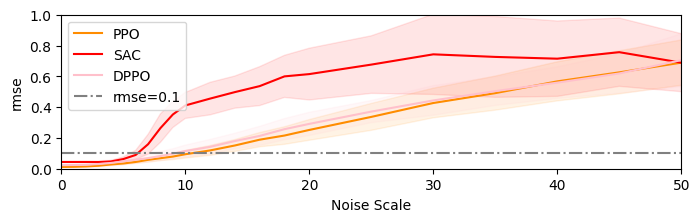

In [22]:
fig = plt.figure(figsize=(8, 2))
for method in metric.keys():
    print(method)
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 200
    count = 0
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - 1*data.std())
        temp_std2.append(data.mean() + 1*data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)
    
    
    #plt.plot(noise_scale[:count+1], temp[:count+1]*100/temp[0], color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(noise_scale[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    print(noise_scale)
    print(temp*100/temp[0])
    ddd = 1 #00/temp[0]
    plt.plot(noise_scale, temp*ddd, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)
ddd= 1#100/gp_mpc_data['rmse_mean'][0]
# plt.plot(noise_scale, gp_mpc_data['rmse_mean'][:13]*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(noise_scale, 
#                  (gp_mpc_data['rmse_mean'][:13]-gp_mpc_data['rmse_std'][:13])*ddd,  
#                  (gp_mpc_data['rmse_mean'][:13]+gp_mpc_data['rmse_std'][:13])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)

#plt.plot(noise_scale, [200]*len(noise_scale), color='grey', linestyle='-.', label='Relative perf = 200%')
plt.plot(noise_scale, [0.1]*len(noise_scale), color='grey', linestyle='-.', label='rmse=0.1')

#plt.text(41, 2000, 'PPO \nearly stop')
#plt.text(6, 1500, 'SAC \nearly stop')
#plt.text(31, 1000, 'DPPO \nearly stop')


plt.legend()
#plt.ylim(0,3000)
plt.ylim(0,1.0)
plt.xlim(0,50)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Noise Scale")
# plt.ylabel("Relative Performance %")
plt.ylabel("rmse")
#plt.title("TD3 for Quadrotor 2D")
#plt.savefig("robustness_ps_rl.pdf",bbox_inches="tight", pad_inches=0.1)

### Robustness metric: Parametric noise

In [23]:
metric = {}
noise_scale = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
# noise_scale = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
noise_scale = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.5, 4.0, 4.5, 5.0]
for method in data_paths.keys():
    print(method)
    metric.update({method: {}})
    for seed in seeds:
        for ns in noise_scale:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_pm_"+str(ns)+".npy"
            file_path = glob.glob(path)
            #print(file_path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            if ns in metric[method].keys():
                metric[method][ns]['rmse'].append(temp['rmse'])
                metric[method][ns]['rmse_std'].append(temp['rmse_std'])
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method][ns]['success'].append(temp2)
            else:
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method].update({ns: {'rmse': [temp['rmse']], 
                                            'rmse_std': [temp['rmse_std']], 
                                            'success': [temp2]}})

PPO
SAC
DPPO


PPO
3.0
[0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.5, 4.0, 4.5, 5.0]
[ 100.          101.62255743  101.08009788  101.89837701  105.57068156
  112.70439408  128.78587453  148.41570046  197.43841756  240.43533078
  227.38406131  283.03048635  325.85830215  292.84727359  499.67235549
  613.06091639  558.92262146  525.91002505  740.98942524  765.45525294
  665.65612605 1090.99167465 1685.53418995 1779.50639182]
[  15.35882835   16.66542442   16.90310213   16.69828642   19.95901512
   25.26193388   36.07762153   47.67753466   88.55816462  101.5820015
   94.87029195  148.30836015  143.67596851  153.53522515  696.29409432
  788.72837798  383.93523889  317.82287226 1033.6720656  1036.38268811
  832.30438185 1919.05354137 2107.95241633 2175.2942484 ]
SAC
2.6
[0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.5, 4.0, 4.5, 5.0]
[100.         100.16732506 100.06908136 100.15497119 100.

Text(0, 0.5, 'Relative Performance %')

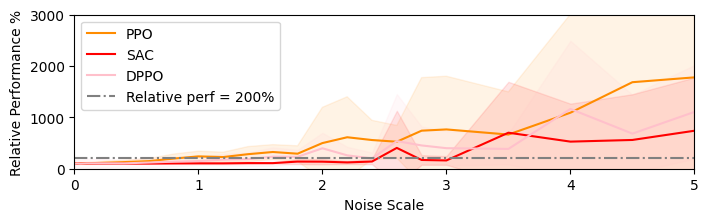

In [24]:
fig = plt.figure(figsize=(8, 2))
for method in metric.keys():
    print(method)
    temp, tempstd, temp_std1, temp_std2 = [], [], [], []
    traj_success_till = 200
    count = 0
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        tempstd.append(data.std())
        temp_std1.append(data.mean() - 1*data.std())
        temp_std2.append(data.mean() + 1*data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    tempstd = np.array(tempstd)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)
    print(noise_scale)
    print(temp*100/temp[0])
    print(tempstd*100/temp[0])
    
    
    #plt.plot(noise_scale[:count+1], temp[:count+1]*100/temp[0], color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(noise_scale[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    ddd = 100/temp[0]
    plt.plot(noise_scale, temp*ddd, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)
ddd= 1#100/gp_mpc_data['rmse_mean'][0]
# plt.plot(noise_scale, gp_mpc_data['rmse_mean'][:13]*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(noise_scale, 
#                  (gp_mpc_data['rmse_mean'][:13]-gp_mpc_data['rmse_std'][:13])*ddd,  
#                  (gp_mpc_data['rmse_mean'][:13]+gp_mpc_data['rmse_std'][:13])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)

plt.plot(noise_scale, [200]*len(noise_scale), color='grey', linestyle='-.', label='Relative perf = 200%')
# plt.plot(noise_scale, [0.1]*len(noise_scale), color='grey', linestyle='-.', label='rmse=0.1')

#plt.text(41, 2000, 'PPO \nearly stop')
#plt.text(6, 1500, 'SAC \nearly stop')
#plt.text(31, 1000, 'DPPO \nearly stop')


plt.legend()
#plt.ylim(0,2)
plt.ylim(0,3000)
plt.xlim(0,5)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Noise Scale")
plt.ylabel("Relative Performance %")
# plt.ylabel("rmse")
# plt.title("TD3 for Quadrotor 2D")
# plt.savefig("robustness_pm_rl.pdf",bbox_inches="tight", pad_inches=0.1)

PPO
3.0
[0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.5, 4.0, 4.5, 5.0]
[0.01229872 0.01249827 0.01243156 0.01253219 0.01298384 0.01386119
 0.01583901 0.01825323 0.02428239 0.02957046 0.02796532 0.03480912
 0.04007639 0.03601646 0.06145329 0.07539863 0.06874031 0.06468019
 0.09113219 0.09414118 0.08186717 0.13417798 0.20729909 0.21885646]
[0.00188894 0.00204963 0.00207886 0.00205368 0.0024547  0.00310689
 0.00443708 0.00586373 0.01089152 0.01249328 0.01166783 0.01824003
 0.0176703  0.01888286 0.08563524 0.09700347 0.04721911 0.03908814
 0.12712841 0.12746178 0.10236276 0.23601897 0.25925111 0.26753329]
SAC
2.6
[0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.5, 4.0, 4.5, 5.0]
[0.04384074 0.04391409 0.04387102 0.04390868 0.04407094 0.04429946
 0.04408259 0.04408301 0.04545656 0.04603992 0.04584094 0.04818964
 0.04777109 0.06097416 0.06030669 0.05384098 0.06147946 0.17776579
 

Text(0, 0.5, 'rmse')

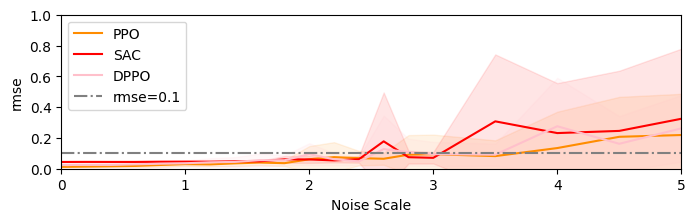

In [25]:
fig = plt.figure(figsize=(8, 2))
for method in metric.keys():
    print(method)
    temp, tempstd, temp_std1, temp_std2 = [], [], [], []
    traj_success_till = 200
    count = 0
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        tempstd.append(data.std())
        temp_std1.append(data.mean() - 1*data.std())
        temp_std2.append(data.mean() + 1*data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    tempstd = np.array(tempstd)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)
    print(noise_scale)
    print(temp)
    print(tempstd)
    
    
    #plt.plot(noise_scale[:count+1], temp[:count+1]*100/temp[0], color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(noise_scale[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    ddd = 1 #00/temp[0]
    plt.plot(noise_scale, temp*ddd, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)
ddd= 1#100/gp_mpc_data['rmse_mean'][0]
# plt.plot(noise_scale, gp_mpc_data['rmse_mean'][:13]*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(noise_scale, 
#                  (gp_mpc_data['rmse_mean'][:13]-gp_mpc_data['rmse_std'][:13])*ddd,  
#                  (gp_mpc_data['rmse_mean'][:13]+gp_mpc_data['rmse_std'][:13])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)

#plt.plot(noise_scale, [200]*len(noise_scale), color='grey', linestyle='-.', label='Relative perf = 200%')
plt.plot(noise_scale, [0.1]*len(noise_scale), color='grey', linestyle='-.', label='rmse=0.1')

#plt.text(41, 2000, 'PPO \nearly stop')
#plt.text(6, 1500, 'SAC \nearly stop')
#plt.text(31, 1000, 'DPPO \nearly stop')


plt.legend()
plt.ylim(0,1.0)
#plt.ylim(0,3000)
plt.xlim(0,5)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Noise Scale")
# plt.ylabel("Relative Performance %")
plt.ylabel("rmse")
# plt.title("TD3 for Quadrotor 2D")
# plt.savefig("robustness_pm_rl.pdf",bbox_inches="tight", pad_inches=0.1)

### Robustness Metric: Downwash

In [26]:
metric = {}
downwash_height = [1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.5, 4.0, 4.5]
for method in data_paths.keys():
    print(method)
    metric.update({method: {}})
    for seed in seeds:
        for ns in downwash_height:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_dw_"+str(ns)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            if ns in metric[method].keys():
                metric[method][ns]['rmse'].append(temp['rmse'])
                metric[method][ns]['rmse_std'].append(temp['rmse_std'])
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method][ns]['success'].append(temp2)
            else:
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method].update({ns: {'rmse': [temp['rmse']], 
                                            'rmse_std': [temp['rmse_std']], 
                                            'success': [temp2]}})

PPO
SAC
DPPO


In [27]:
# gp_name = 'nominal/gpmpc_acados_TP_downwash_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# print(gp_mpc_data['rmse_mean'][:13])
# print(gp_mpc_data.keys())
# print(gp_mpc_data['dw_height'])

PPO
50
SAC
50
DPPO
50


Text(0, 0.5, 'rmse')

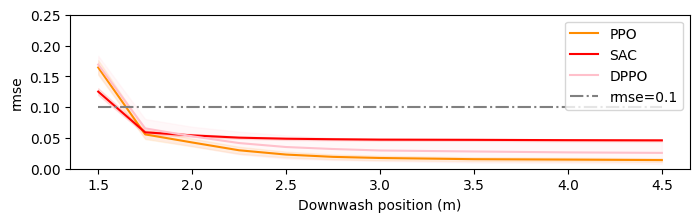

In [28]:
fig = plt.figure(figsize=(8, 2))

for method in metric.keys():
    print(method)
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 50
    count = 50
    for k, ns in enumerate(downwash_height):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)

    ddd = 1 #100/temp[-1]
    plt.plot(downwash_height, temp*ddd, color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(downwash_height[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    plt.fill_between(downwash_height, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

# ddd = 100/gp_mpc_data['rmse_mean'][-1]
# plt.plot(gp_mpc_data['dw_height'], gp_mpc_data['rmse_mean']*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(gp_mpc_data['dw_height'], 
#                  (gp_mpc_data['rmse_mean']-gp_mpc_data['rmse_std'])*ddd,  
#                  (gp_mpc_data['rmse_mean']+gp_mpc_data['rmse_std'])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)
plt.plot(downwash_height, [0.1]*len(downwash_height), color='grey', linestyle='-.', label='rmse=0.1')
#plt.text(16, 100, 'PPO \nearly stop')
#plt.text(31, 500, 'SAC \nearly stop')
#plt.text(11, 100, 'DPPO \nearly stop')


plt.legend()
#plt.ylim(0,1000)
plt.ylim(0,0.25)
#plt.xlim(0,50)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Downwash position (m)")
plt.ylabel("rmse")
#plt.title("TD3 for Quadrotor 2D")
# plt.savefig("robustness_dw_rl.pdf",bbox_inches="tight", pad_inches=0.1)

### Rough plots for individual seeds

In [16]:
colors = {
    "ref": "black",
    "PPO": "orange",
    "PPO2": "red",
    "PPO3": "tab:cyan",
    "PPO4": "royalblue",
    "DPPO": "darkorange",
    "DPPO2": "red",
    "DPPO3": "tab:cyan",
    "DPPO4": "royalblue",
    "SAC": "royalblue",
    "iLQR": "tab:gray",
}
legends = {
    "PPO": "PPO",
    "PPO2": "2",
    "PPO3": "3",
    "PPO4": "4",
    "DPPO": "DPPO",
    "DPPO2": "2",
    "DPPO3": "3",
    "DPPO4": "4",
    "SAC": "SAC"
}
seeds = [i for i in range(0,5)]

In [18]:
data_paths = {
    "PPO": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data/",
    #"PPO2": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data2/",
    #"PPO3": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data3/",
    #"PPO4": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data4/",
    #"DPPO": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data/",
    #"DPPO2": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data2/",
    #"DPPO3": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data3/",
    #"DPPO4": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data4/",
    
    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Test_runs/quadrotor_2D_attitude_ppo_data/',

    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_ppo_data/',
    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_ppo_data2/',
    #'DPPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_dppo_data2/',
    #'SAC': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_sac_data2/',
    
    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data/',
    #'PPO2': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data2/',
    #'PPO3': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data3/',
    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data2/',
    #'DPPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_dppo_data/',
    #'DPPO2': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_dppo_data2/',
    #'DPPO3': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_dppo_data3/',
    
}

perf_data = {}
for method in data_paths.keys():
    print(method)
    perf_data.update({method: {}})
    for seed in seeds:
        # print(data_paths[method] + str(seed) + "/logs/stat_eval/ep_length.log")
        xk, x, lk, l = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/ep_length.log")
        xk, x, yk, y = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/ep_return.log")
        xk, x, zk, z = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/ep_return_std.log")
        # xk, x, ck, c = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/constraint_violation.log")
        # perf_data[method].update({seed: {"x": x, "y": y, "c": c}})
        # perf_data[method].update({seed: {"x": x, "y": y, "z": z, "c": c}})
        xk, x, yk, m = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/rmse.log")
        xk, x, yk, n = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/rmse_std.log")
        # perf_data[method].update({"x": x, "y": y, "z": z, "x1": x1, "y1": y1, "z1": z1})
        perf_data[method].update({seed: {"x": x, "y": y, "z": z, "m": m, "n": n, "l": l}})

PPO


In [144]:
eval_data = {}
w = 1
fig = plt.figure(figsize=(8, 3))
mean_fn = np.percentile
perc = 90
plot_seeds = True

for t, method in enumerate(data_paths.keys()):
    print(method)
    temp = np.zeros((len(seeds), 6, perf_data[method][seeds[0]]["x"].shape[0]))
    for seed in seeds:
        temp[seed, 0, :] = perf_data[method][seed]["x"]
        temp[seed, 1, :] = perf_data[method][seed]["y"]
        temp[seed, 2, :] = perf_data[method][seed]["z"]
        temp[seed, 3, :] = perf_data[method][seed]["m"]
        temp[seed, 4, :] = perf_data[method][seed]["n"]
        temp[seed, 5, :] = perf_data[method][seed]["l"]
    j_max = 0
    for seed in seeds:
        for j,k in enumerate(temp[seed, 0, :]):
            if temp[seed, 5, j] < 660:
                temp[seed, 1, j] = np.nan
                temp[seed, 2, j] = np.nan
                temp[seed, 3, j] = np.nan
                temp[seed, 4, j] = np.nan
    eval_data.update({method: temp})

    # plot
    plt.plot(temp[0,0,:], mean_fn(temp[:,3,:], perc, axis=0), color=colors[method], label=legends[method])
    plt.fill_between(temp[0,0,:], 
                     np.clip(mean_fn(temp[:,3,:]+w*temp[:,4,:], perc, axis=0), 0, 10),  
                     np.clip(mean_fn(temp[:,3,:]-w*temp[:,4,:], perc, axis=0), 0, 10), color=colors[method], alpha=0.2)
    if plot_seeds:
        for seed in seeds:
            plt.plot(temp[seed,0,:], temp[seed,3,:], label=seed)
            plt.fill_between(temp[0,0,:], 
                             np.clip(temp[seed,3,:]-w*temp[seed,4,:], 0, 10),  
                             np.clip(temp[seed,3,:]+w*temp[seed,4,:], 0, 10), alpha=0.)



# s = 1 # time std
# rmse_ilqr_mean = 0.026000000000000002 * 0
# rmse_ilqr_std = 0.001843908891458577 * 0
plt.axhline(xmin=0.0, xmax=1.95, y=0.1, linestyle='-.', color=colors["iLQR"], label='rmse=0.1')
# plt.fill_between([0.0, last_iter], rmse_ilqr_mean-s*rmse_ilqr_std, rmse_ilqr_mean+s*rmse_ilqr_std, color=colors["iLQR"], alpha=0.25)

# real experiment data
# plt.plot(last_iter, 0.086, color=colors['PPO'], marker='x')
# plt.plot(last_iter, 0.064, color=colors['SAC'], marker='x')

plt.legend(ncol=3)
# plt.ylim(-200,00)
# plt.xlim(right=6e5)
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training steps")
plt.ylabel("RMSE")
#plt.title("Task: Quadrotor 2D")
#plt.savefig("performance_logx.pdf",bbox_inches="tight", pad_inches=0.0)

PPO


KeyError: 'x'

<Figure size 800x300 with 0 Axes>

In [7]:
mean_fn = np.mean
for method in eval_data.keys():
    print(method)
    print(mean_fn(eval_data[method][:, 3, :], axis=0))

PPO
[       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan 0.26790361 0.22807108 0.18980713 0.16330053 0.13762581
 0.1207609  0.10932789 0.0900497  0.07063229 0.0585894  0.0466095
 0.0460997  0.04961646 0.04840762 0.04278864 0.03734574 0.03677834
 0.03701848 0.03908621 0.03867297 0.0360975  0.03486813 0.04169359
 0.03725969 0.03457009 0.03849986 0.03885277 0.0400471  0.04342527
 0.041256   0.0388206  0.03144821 0.03468308 0.03563006 0.03330509
 0.03826558 0.07731813]
DPPO
[       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan 0.25586162 0.24190134 0.22537191 0.20194781 0.18302899
 0.17394095 0.15722846 0.13726